In [ ]:
# Importing core data manipulation, operating system, and visualization libraries
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import os  

In [ ]:
# Read the primary dataset from the local downloads directory
df = pd.read_csv('c:/Users/sande/Downloads/netflix_titles.csv')

In [3]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [ ]:
# Display the first 2 rows of the DataFrame to inspect the column structure and sample data
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Check for missing values by calculating the total sum of null (NaN) items in each column
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [32]:
# DATA CLEANING, IMPUTATION & TEXT STANDARDIZATION

# Define a dictionary mapping columns to specific placeholder strings for missing values
df_fill =  {
    'director': 'unknown director',
    'cast' : 'unknown cast',
    'country' : 'unknown country',
    'date_added' : 'unknown date_added',
    'rating' : 'unknown rating',
    'duration':'unknown duration'
}

# Fill all missing (NaN) values in the specified columns permanently
df.fillna(df_fill,inplace=True)

# Remove any duplicate rows present in the dataset permanently
df.drop_duplicates(inplace=True)

# Standardize text data: Convert all values to strings, lowercase them, trim whitespaces, and replace spaces with underscores
df = df.apply(lambda x : x.astype(str).str.lower().str.strip().str.replace(' ','_'))

# Standardize column headers: Convert to lowercase, trim whitespaces, and replace spaces with underscores
df.columns = df.columns.str.lower().str.strip().str.replace(' ','_')

# Display the first 5 records to verify cleaning and formatting changes
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,movie,dick_johnson_is_dead,kirsten_johnson,unknown_cast,united_states,"september_25,_2021",2020,pg-13,90_min,documentaries,"as_her_father_nears_the_end_of_his_life,_filmm..."
1,s2,tv_show,blood_&_water,unknown_director,"ama_qamata,_khosi_ngema,_gail_mabalane,_thaban...",south_africa,"september_24,_2021",2021,tv-ma,2_seasons,"international_tv_shows,_tv_dramas,_tv_mysteries","after_crossing_paths_at_a_party,_a_cape_town_t..."
2,s3,tv_show,ganglands,julien_leclercq,"sami_bouajila,_tracy_gotoas,_samuel_jouy,_nabi...",unknown_country,"september_24,_2021",2021,tv-ma,1_season,"crime_tv_shows,_international_tv_shows,_tv_act...",to_protect_his_family_from_a_powerful_drug_lor...
3,s4,tv_show,jailbirds_new_orleans,unknown_director,unknown_cast,unknown_country,"september_24,_2021",2021,tv-ma,1_season,"docuseries,_reality_tv","feuds,_flirtations_and_toilet_talk_go_down_amo..."
4,s5,tv_show,kota_factory,unknown_director,"mayur_more,_jitendra_kumar,_ranjan_raj,_alam_k...",india,"september_24,_2021",2021,tv-ma,2_seasons,"international_tv_shows,_romantic_tv_shows,_tv_...",in_a_city_of_coaching_centers_known_to_train_i...


In [31]:
df.isnull().sum() / len(df) * 100

show_id         0.0
type            0.0
title           0.0
director        0.0
cast            0.0
country         0.0
date_added      0.0
release_year    0.0
rating          0.0
duration        0.0
listed_in       0.0
description     0.0
dtype: float64

In [33]:
# Extract and display all unique classification values from the 'rating' column
print(df["rating"].unique())

<StringArray>
[         'pg-13',          'tv-ma',             'pg',          'tv-14',
          'tv-pg',           'tv-y',          'tv-y7',              'r',
           'tv-g',              'g',          'nc-17',         '74_min',
         '84_min',         '66_min',             'nr', 'unknown_rating',
       'tv-y7-fv',             'ur']
Length: 18, dtype: str


In [34]:
# Check the final dimensions of the DataFrame, returning a tuple showing (total_rows, total_columns)
df.shape

(8807, 12)

In [36]:
# Isolate rows where the production origin is strictly listed as the United States
united_states_data = df[df["country"] == "united_states"]

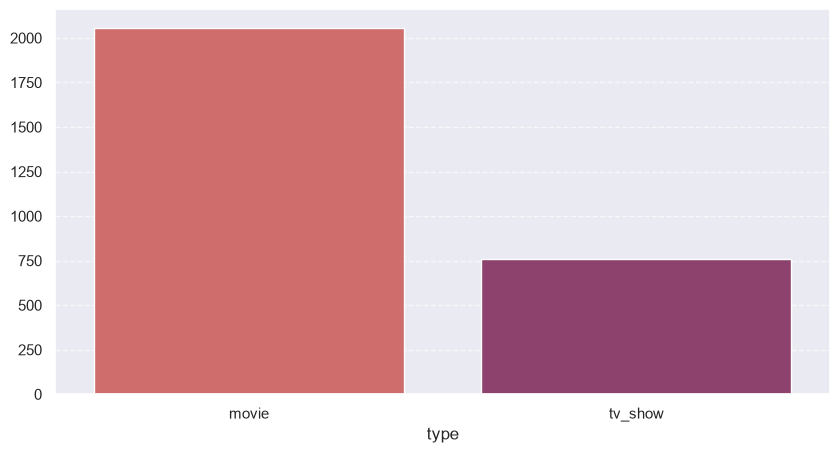

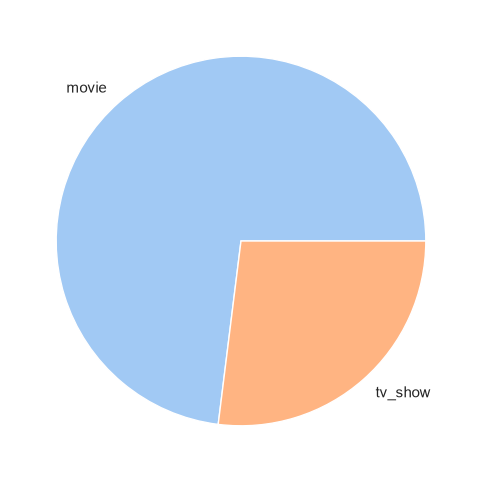

In [ ]:
# DATA VISUALIZATION - UNITED STATES METRICS


# Calculate total frequency counts for each individual category within the 'type' column
united_states_data_type = united_states_data.type.value_counts()

# --- Plot 1: Bar Chart ---
# Instantiate a fresh canvas figure window with dimensions optimized for a bar plot
plt.figure(figsize=(10, 5))

# Generate a vertical bar plot mapping unique categories to their specific counts
# 'hue' is assigned to map categories to the 'flare' color palette without warnings
sns.barplot(
    x=united_states_data_type.index,
    y=united_states_data_type.values,
    hue=united_states_data_type.index,
    palette="flare",
    legend=False,
)

# Force grid background elements to be drawn beneath the visible bars
plt.gca().set_axisbelow(True)

# Render dashed tracking lines across the horizontal Y-axis layer only
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Render and clear the canvas for the bar chart window
plt.show()


# --- Plot 2: Pie Chart ---
# Create a dedicated, square canvas layout to ensure the circle doesn't distort
plt.figure(figsize=(6, 6))

# Construct a traditional pie chart split directly by our aggregated metrics
plt.pie(united_states_data_type.values, labels=united_states_data_type.index)

# Render and clear the canvas for the pie chart window
plt.show()